In [1]:
from pathlib import Path
import os

# Resolve project root regardless of where Jupyter was launched from.
# Walks up from CWD until pyproject.toml is found, then sets CWD there
# so all relative paths (data/, models/) resolve correctly.
_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'pyproject.toml').exists()
)
os.chdir(_root)

## APS Failure at Scania Trucks

>**The data comes from:** https://archive.ics.uci.edu/dataset/421/aps+failure+at+scania+trucks

## Data Loading and Exploration

#### Importing the libraries

In [2]:
# Notebook 1 of 3 — EDA & Preprocessing
# Outputs: data/processed/ (feature matrices + labels for notebook 02)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, SMOTENC

from aps.preprocessing import ColumnDropper, build_feature_pipeline, downsample_majority_class

In [3]:
df_training = pd.read_csv('data/aps_failure_training_set.csv', sep=',', skiprows=20, na_values='na')
df_test = pd.read_csv('data/aps_failure_test_set.csv', sep=',', skiprows=20, na_values='na')
cost_dict = {}

In [4]:
df_training.head() 

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


In [5]:
df_test.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,60,0.0,20.0,12.0,0.0,0.0,0.0,0.0,0.0,...,1098.0,138.0,412.0,654.0,78.0,88.0,0.0,0.0,0.0,0.0
1,neg,82,0.0,68.0,40.0,0.0,0.0,0.0,0.0,0.0,...,1068.0,276.0,1620.0,116.0,86.0,462.0,0.0,0.0,0.0,0.0
2,neg,66002,2.0,212.0,112.0,0.0,0.0,0.0,0.0,0.0,...,495076.0,380368.0,440134.0,269556.0,1315022.0,153680.0,516.0,0.0,0.0,0.0
3,neg,59816,NaN,1010.0,936.0,0.0,0.0,0.0,0.0,0.0,...,540820.0,243270.0,483302.0,485332.0,431376.0,210074.0,281662.0,3232.0,0.0,0.0
4,neg,1814,NaN,156.0,140.0,0.0,0.0,0.0,0.0,0.0,...,7646.0,4144.0,18466.0,49782.0,3176.0,482.0,76.0,0.0,0.0,0.0


In [6]:
df_training.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), str(1)
memory usage: 78.4 MB


In [7]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), str(1)
memory usage: 20.9 MB


In [8]:
df_training.describe()

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
count,6.000000e+04,13671.000000,5.666500e+04,4.513900e+04,57500.000000,57500.000000,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,...,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,5.932900e+04,57276.000000,57277.000000
mean,5.933650e+04,0.713189,3.560143e+08,1.906206e+05,6.819130,11.006817,2.216364e+02,9.757223e+02,8.606015e+03,8.859128e+04,...,4.454897e+05,2.111264e+05,4.457343e+05,3.939462e+05,3.330582e+05,3.462714e+05,1.387300e+05,8.388915e+03,0.090579,0.212756
std,1.454301e+05,3.478962,7.948749e+08,4.040441e+07,161.543373,209.792592,2.047846e+04,3.420053e+04,1.503220e+05,7.617312e+05,...,1.155540e+06,5.433188e+05,1.168314e+06,1.121044e+06,1.069160e+06,1.728056e+06,4.495100e+05,4.747043e+04,4.368855,8.830641
min,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,8.340000e+02,0.000000,1.600000e+01,2.400000e+01,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.936000e+03,1.166000e+03,2.700000e+03,3.584000e+03,5.120000e+02,1.100000e+02,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,3.077600e+04,0.000000,1.520000e+02,1.260000e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.337960e+05,1.120860e+05,2.215180e+05,1.899880e+05,9.243200e+04,4.109800e+04,3.812000e+03,0.000000e+00,0.000000,0.000000
75%,4.866800e+04,0.000000,9.640000e+02,4.300000e+02,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.383960e+05,2.182320e+05,4.666140e+05,4.032220e+05,2.750940e+05,1.678140e+05,1.397240e+05,2.028000e+03,0.000000,0.000000
max,2.746564e+06,204.000000,2.130707e+09,8.584298e+09,21050.000000,20070.000000,3.376892e+06,4.109372e+06,1.055286e+07,6.340207e+07,...,7.793393e+07,3.775839e+07,9.715238e+07,5.743524e+07,3.160781e+07,1.195801e+08,1.926740e+07,3.810078e+06,482.000000,1146.000000


In [9]:
df_test.describe()

,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
count,1.600000e+04,3637.000000,1.507400e+04,12019.000000,15310.000000,15310.000000,15811.000000,1.581100e+04,1.581100e+04,1.581100e+04,...,1.580800e+04,1.580800e+04,1.580800e+04,1.580800e+04,1.580800e+04,1.580800e+04,1.580800e+04,1.580800e+04,15238.000000,15238.000000
mean,6.799698e+04,0.772065,3.580393e+08,439.498794,6.428347,10.195950,120.858516,2.064204e+03,1.379236e+04,1.126276e+05,...,4.649135e+05,2.212010e+05,4.690886e+05,4.256696e+05,3.559239e+05,3.524014e+05,1.442759e+05,8.560355e+03,0.064969,0.242683
std,5.035350e+05,2.589224,7.966968e+08,1551.328109,118.186469,167.260463,6454.660300,8.925778e+04,2.358405e+05,1.025843e+06,...,1.255197e+06,5.828691e+05,1.267550e+06,1.259560e+06,1.199544e+06,1.628545e+06,5.368225e+05,5.329946e+04,3.374657,14.339059
min,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,9.280000e+02,0.000000,1.600000e+01,26.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,...,3.178000e+03,1.256000e+03,2.883500e+03,3.869500e+03,6.100000e+02,1.240000e+02,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,3.098200e+04,0.000000,1.590000e+02,130.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,...,2.409860e+05,1.147800e+05,2.297080e+05,1.956510e+05,9.657000e+04,4.201300e+04,3.985000e+03,0.000000e+00,0.000000,0.000000
75%,4.947900e+04,0.000000,1.003500e+03,430.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,...,4.391320e+05,2.189510e+05,4.714860e+05,4.034105e+05,2.790355e+05,1.699100e+05,1.389310e+05,1.907000e+03,0.000000,0.000000
max,4.294967e+07,58.000000,2.130707e+09,87038.000000,11044.000000,14186.000000,736174.000000,1.047252e+07,1.914916e+07,7.305747e+07,...,5.382333e+07,2.207969e+07,4.859750e+07,5.604348e+07,4.215944e+07,4.747137e+07,1.718575e+07,4.570398e+06,340.000000,1720.000000


## Data Preprocessing

### >Data Cleaning

### Handling missing values

In [10]:
round((df_test.isnull().sum()/df_test.shape[0])*100,2)

class      0.00
aa_000     0.00
ab_000    77.27
ac_000     5.79
ad_000    24.88
          ...  
ee_007     1.20
ee_008     1.20
ee_009     1.20
ef_000     4.76
eg_000     4.76
Length: 171, dtype: float64

In [11]:
round((df_training.isnull().sum()/df_training.shape[0])*100,2)

class      0.00
aa_000     0.00
ab_000    77.22
ac_000     5.56
ad_000    24.77
          ...  
ee_007     1.12
ee_008     1.12
ee_009     1.12
ef_000     4.54
eg_000     4.54
Length: 171, dtype: float64

In [12]:
df_training.isnull().sum()

class         0
aa_000        0
ab_000    46329
ac_000     3335
ad_000    14861
          ...  
ee_007      671
ee_008      671
ee_009      671
ef_000     2724
eg_000     2723
Length: 171, dtype: int64

In [13]:
df_test.isnull().sum()

class         0
aa_000        0
ab_000    12363
ac_000      926
ad_000     3981
          ...  
ee_007      192
ee_008      192
ee_009      192
ef_000      762
eg_000      762
Length: 171, dtype: int64

### Visualizing 'na' values with a heatmap

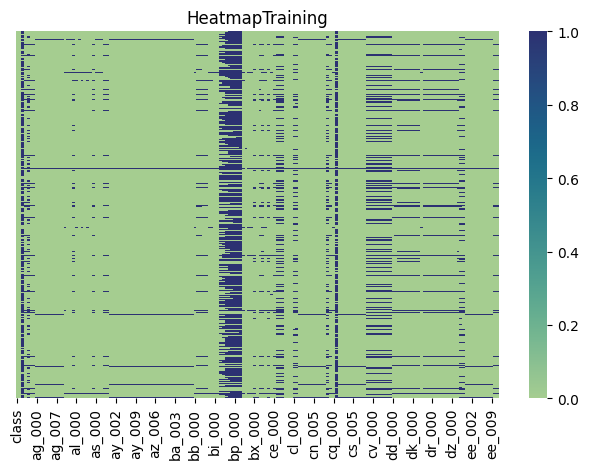

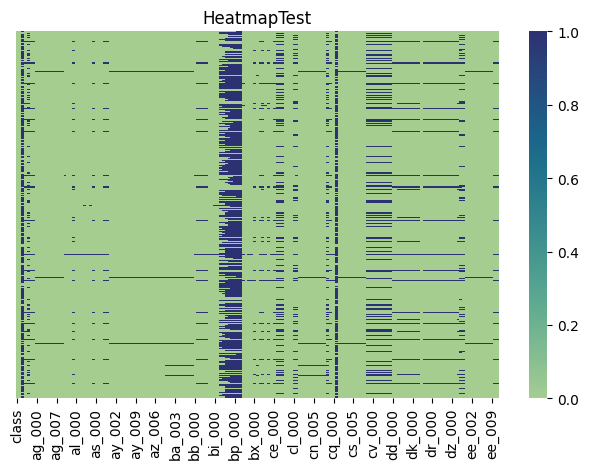

In [14]:
def plot_missing_values_heatmap(df, name):
    """
    Generate heatmaps to visualize missing values in the training and test datasets.

    Args:
        df_train (DataFrame): The training dataset.
        df_test (DataFrame): The test dataset.
    """
    # Plot heatmap for training set
    
    sns.heatmap(df.isna(), yticklabels=False, cmap='crest')
    plt.title('Heatmap' + name)
    plt.tight_layout()
    plt.show()

plot_missing_values_heatmap(df_training, name='Training')
plot_missing_values_heatmap(df_test, name='Test')

In [15]:
df_training.tail()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
59995,neg,153002,NaN,6.640000e+02,186.0,0.0,0.0,0.0,0.0,0.0,...,998500.0,566884.0,1290398.0,1218244.0,1019768.0,717762.0,898642.0,28588.0,0.0,0.0
59996,neg,2286,NaN,2.130707e+09,224.0,0.0,0.0,0.0,0.0,0.0,...,10578.0,6760.0,21126.0,68424.0,136.0,0.0,0.0,0.0,0.0,0.0
59997,neg,112,0.0,2.130706e+09,18.0,0.0,0.0,0.0,0.0,0.0,...,792.0,386.0,452.0,144.0,146.0,2622.0,0.0,0.0,0.0,0.0
59998,neg,80292,NaN,2.130706e+09,494.0,0.0,0.0,0.0,0.0,0.0,...,699352.0,222654.0,347378.0,225724.0,194440.0,165070.0,802280.0,388422.0,0.0,0.0
59999,neg,40222,NaN,6.980000e+02,628.0,0.0,0.0,0.0,0.0,0.0,...,440066.0,183200.0,344546.0,254068.0,225148.0,158304.0,170384.0,158.0,0.0,0.0


In [16]:
df_test.tail()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
15995,neg,81852,NaN,2.130706e+09,892.0,0.0,0.0,0.0,0.0,0.0,...,632658.0,273242.0,510354.0,373918.0,349840.0,317840.0,960024.0,25566.0,0.0,0.0
15996,neg,18,0.0,5.200000e+01,46.0,8.0,26.0,0.0,0.0,0.0,...,266.0,44.0,46.0,14.0,2.0,0.0,0.0,0.0,0.0,0.0
15997,neg,79636,NaN,1.670000e+03,1518.0,0.0,0.0,0.0,0.0,0.0,...,806832.0,449962.0,778826.0,581558.0,375498.0,222866.0,358934.0,19548.0,0.0,0.0
15998,neg,110,NaN,3.600000e+01,32.0,0.0,0.0,0.0,0.0,0.0,...,588.0,210.0,180.0,544.0,1004.0,1338.0,74.0,0.0,0.0,0.0
15999,neg,8,0.0,6.000000e+00,4.0,2.0,2.0,0.0,0.0,0.0,...,46.0,10.0,48.0,14.0,42.0,46.0,0.0,0.0,0.0,0.0


### Dropping columns with at least 50% missing values

In [17]:
# ColumnDropper is fit on features only (class column excluded) so the fitted
# object works on raw sensor data at inference time where no label is present.
df_training.replace('na', float('nan'), inplace=True)
df_test.replace('na', float('nan'), inplace=True)

col_dropper = ColumnDropper(threshold=0.5).fit(df_training.drop(columns=['class']))

# Apply to features then reattach label for EDA and training
df_training_cleaned = pd.concat(
    [df_training[['class']], col_dropper.transform(df_training.drop(columns=['class']))],
    axis=1)
df_test_cleaned = pd.concat(
    [df_test[['class']], col_dropper.transform(df_test.drop(columns=['class']))],
    axis=1)

print(f'Train: {df_training.shape[1]} columns -> {df_training_cleaned.shape[1]} columns')
print(f'Test:  {df_test.shape[1]}     columns -> {df_test_cleaned.shape[1]} columns')


ColumnDropper: dropping 8 columns (>=50% missing): ['ab_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'cr_000']
Train: 171 columns -> 163 columns
Test:  171     columns -> 163 columns


### Median imputation with missing-value indicator columns


In [18]:
# preprocess_dataframe is now MedianImputerWithIndicators in src/aps/preprocessing.py.
# It is applied via build_feature_pipeline() in the split cell below.

### Plotting Boxplot

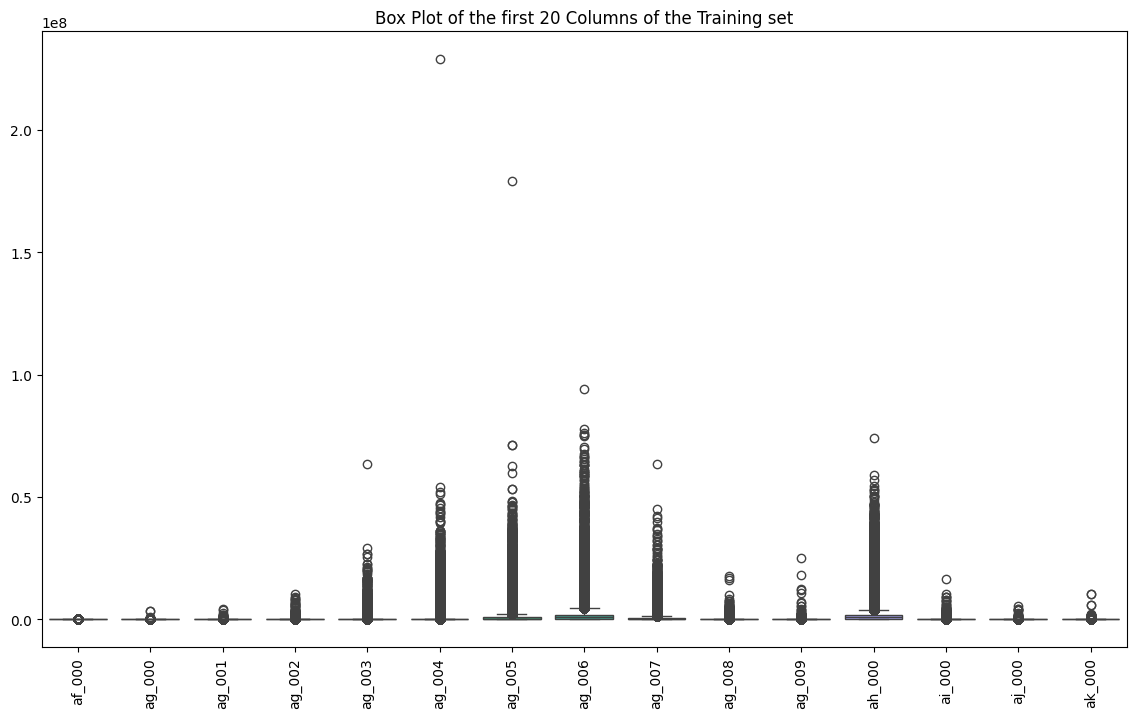

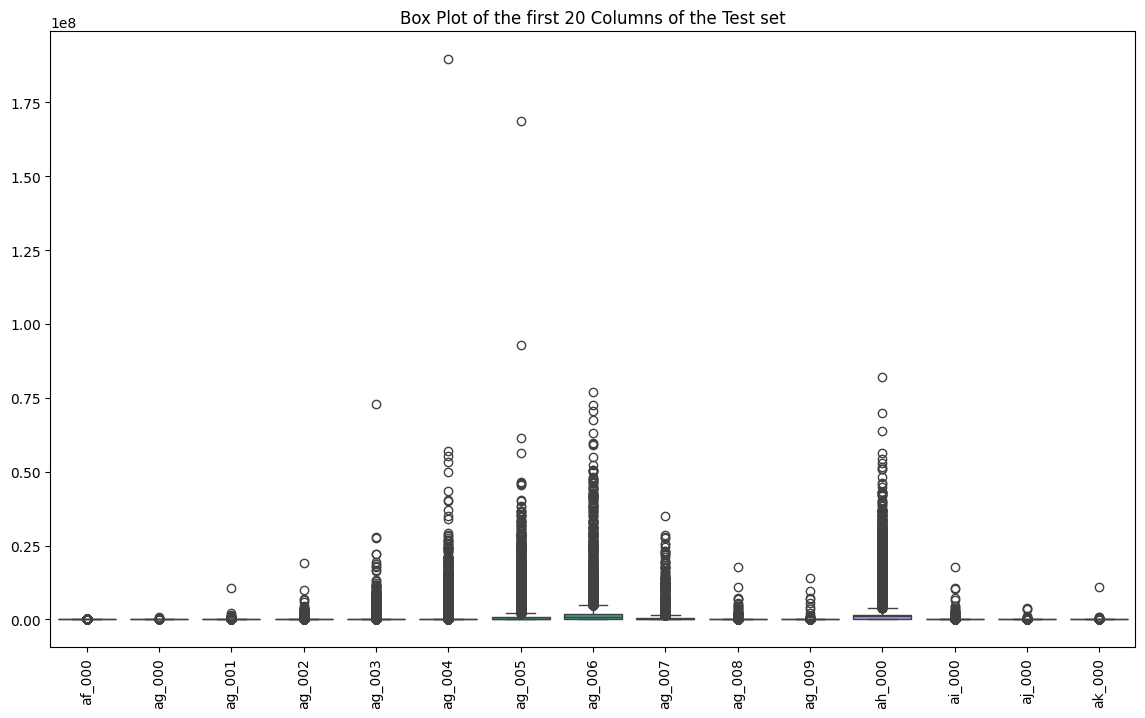

In [19]:
def plot_boxplot(df, name):
    """
    Plot boxplots for the first 20 columns of the DataFrame.

    Args:
        df (pd.DataFrame): The DataFrame to process.

    Returns:
        None
    """
    columns_to_plot = df.columns[5:20]
    
    # Create the boxplots
    plt.figure(figsize=(14, 8))
    plt.title(name)
    sns.boxplot(data=df[columns_to_plot])
    plt.xticks(rotation=90)
    plt.show()

plot_boxplot(df_training_cleaned, name='Box Plot of the first 20 Columns of the Training set')
plot_boxplot(df_test_cleaned, name='Box Plot of the first 20 Columns of the Test set')

### Heatmap

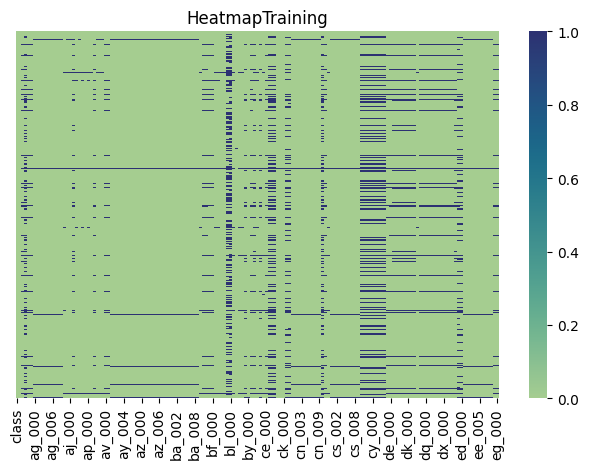

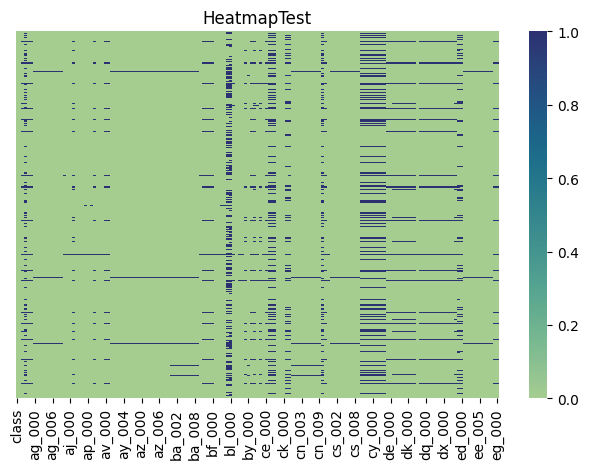

In [20]:
plot_missing_values_heatmap(df_training_cleaned, name='Training')
plot_missing_values_heatmap(df_test_cleaned, name='Test')

### Correlation matrix

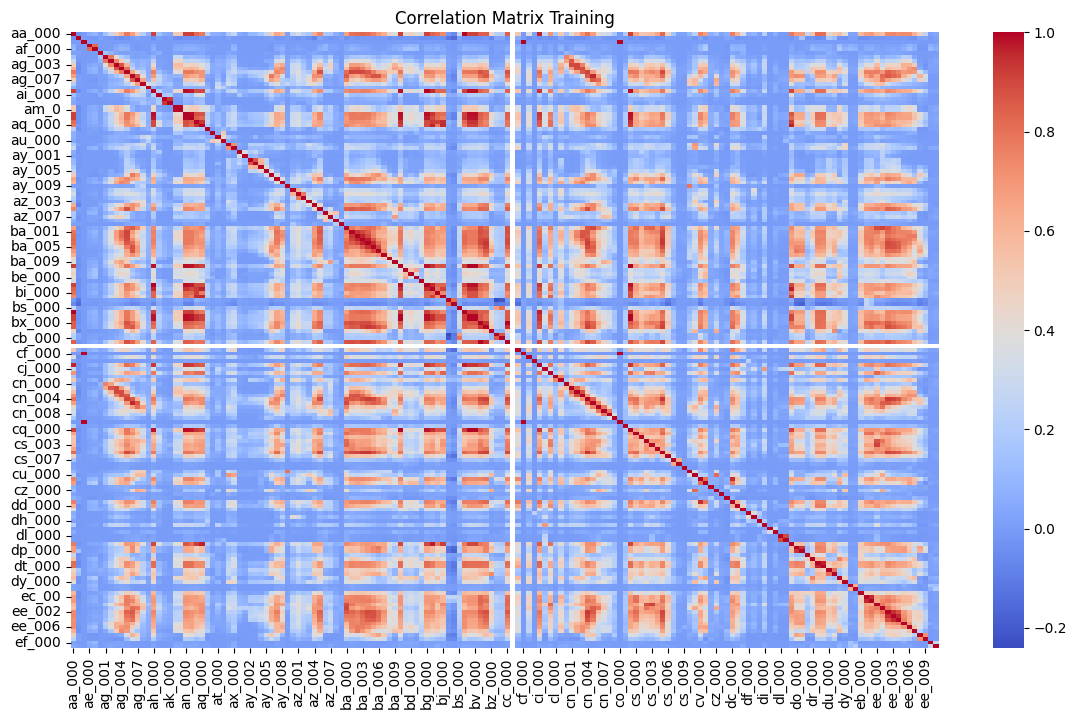

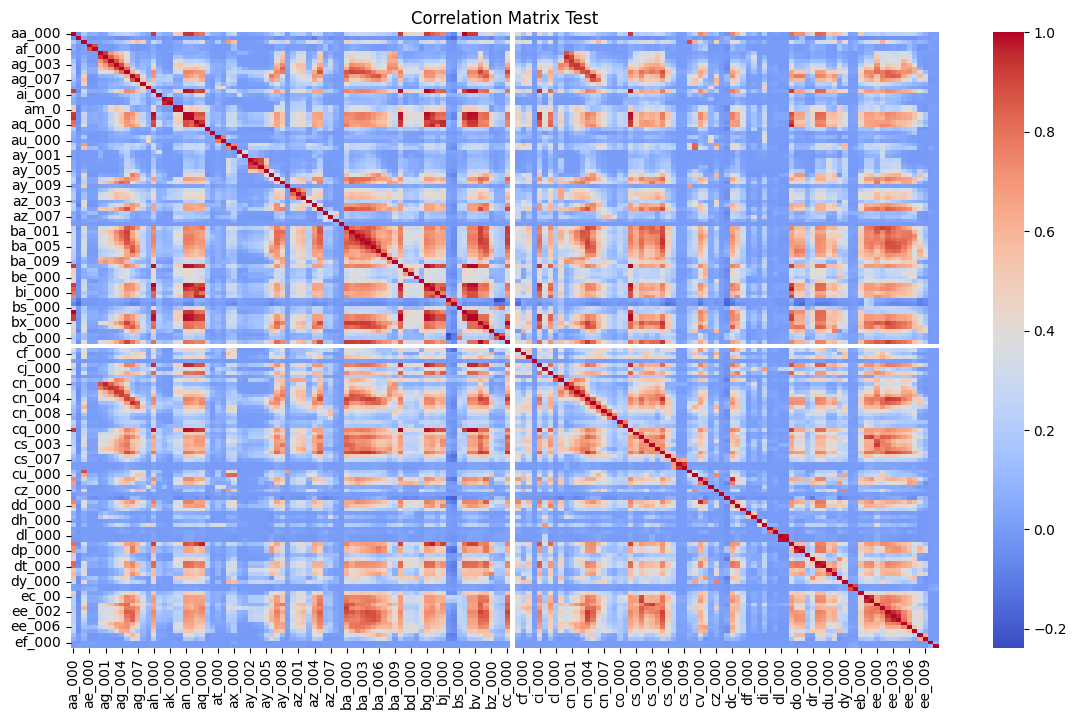

In [21]:
def plot_correlation_matrix(df, name):
    '''Plot correlation matrix, excluding the class column.
    annot=True omitted — with 170+ features the text completely overlaps.
    '''
    corr_matrix = df.iloc[:, 1:].corr()
    plt.figure(figsize=(14, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm')
    plt.title('Correlation Matrix ' + name)
    plt.show()

plot_correlation_matrix(df_training_cleaned, name='Training')
plot_correlation_matrix(df_test_cleaned, name='Test')


In [22]:
df_training_cleaned.info()
df_training_cleaned.describe()
df_training_cleaned.tail()
df_training_cleaned.iloc[:20,:]

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 163 entries, class to eg_000
dtypes: float64(161), int64(1), str(1)
memory usage: 74.8 MB


,class,aa_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,318.0,...,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,0.0,...,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0
5,neg,38312,2.130706e+09,218.0,0.0,0.0,0.0,0.0,0.0,0.0,...,388574.0,288278.0,900430.0,300412.0,1534.0,338.0,856.0,0.0,0.0,0.0
6,neg,14,6.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,168.0,48.0,60.0,28.0,0.0,0.0,0.0,0.0,0.0,0.0
7,neg,102960,2.130706e+09,116.0,0.0,0.0,0.0,0.0,0.0,0.0,...,715518.0,384948.0,915978.0,1052166.0,1108672.0,341532.0,129504.0,7832.0,0.0,0.0
8,neg,78696,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,699290.0,362510.0,1190028.0,1012704.0,160090.0,63216.0,41202.0,4.0,0.0,0.0
9,pos,153204,1.820000e+02,NaN,0.0,0.0,0.0,0.0,0.0,11804.0,...,129862.0,26872.0,34044.0,22472.0,34362.0,0.0,0.0,0.0,0.0,0.0


In [23]:
df_test_cleaned.info()
df_test_cleaned.describe()
df_test_cleaned.tail()
df_test_cleaned.iloc[:20,:]

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Columns: 163 entries, class to eg_000
dtypes: float64(161), int64(1), str(1)
memory usage: 19.9 MB


,class,aa_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,60,2.000000e+01,12.0,0.0,0.0,0.0,0.0,0.0,2682.0,...,1098.0,138.0,412.0,654.0,78.0,88.0,0.0,0.0,0.0,0.0
1,neg,82,6.800000e+01,40.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1068.0,276.0,1620.0,116.0,86.0,462.0,0.0,0.0,0.0,0.0
2,neg,66002,2.120000e+02,112.0,0.0,0.0,0.0,0.0,0.0,199486.0,...,495076.0,380368.0,440134.0,269556.0,1315022.0,153680.0,516.0,0.0,0.0,0.0
3,neg,59816,1.010000e+03,936.0,0.0,0.0,0.0,0.0,0.0,0.0,...,540820.0,243270.0,483302.0,485332.0,431376.0,210074.0,281662.0,3232.0,0.0,0.0
4,neg,1814,1.560000e+02,140.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7646.0,4144.0,18466.0,49782.0,3176.0,482.0,76.0,0.0,0.0,0.0
5,neg,174,2.600000e+01,24.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
6,neg,40202,6.400000e+02,606.0,0.0,0.0,0.0,0.0,0.0,0.0,...,526218.0,239734.0,439556.0,374248.0,169096.0,53658.0,41054.0,320.0,0.0,0.0
7,neg,120278,2.130706e+09,256.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1006722.0,459658.0,876356.0,689532.0,568540.0,500624.0,1006628.0,34820.0,0.0,0.0
8,neg,14592,2.130706e+09,162.0,0.0,0.0,0.0,0.0,0.0,0.0,...,105024.0,57398.0,49152.0,38256.0,243268.0,145144.0,0.0,0.0,0.0,0.0
9,neg,28338,2.130706e+09,238.0,0.0,0.0,0.0,0.0,0.0,0.0,...,357006.0,150056.0,264776.0,239282.0,140548.0,74750.0,32958.0,84.0,0.0,0.0


## Dataset splitting

### Undersampling

In [24]:
# ── Step 1: 80/20 stratified split — BEFORE preprocessing ───────────────────
strat = (df_training_cleaned['class'] == 'pos').astype(int)
df_train_raw, df_val_raw = train_test_split(
    df_training_cleaned, test_size=0.20, random_state=42, stratify=strat)

# ── Step 2–3: Imputation + Winsorisation — fit on 80% split only ─────────────
# build_feature_pipeline() chains MedianImputerWithIndicators → WinsorizerTransformer.
# fit_transform on train; transform (no refit) on val and test.
X_train_raw = df_train_raw.drop(columns=['class'])
X_val_raw   = df_val_raw.drop(columns=['class'])
X_test_raw  = df_test_cleaned.drop(columns=['class'])

y_train_fit = (df_train_raw['class'] == 'pos').astype(int).to_numpy()
y_val       = (df_val_raw['class']   == 'pos').astype(int).to_numpy()
y_test      = (df_test_cleaned['class'] == 'pos').astype(int).to_numpy()

feature_pipeline = build_feature_pipeline(missing_threshold=0.20, iqr_scale=3.0)
X_train_fit = feature_pipeline.fit_transform(X_train_raw)
X_val       = feature_pipeline.transform(X_val_raw)
X_test      = feature_pipeline.transform(X_test_raw)

print(f'Train-fit  : {len(X_train_fit)} rows, pos rate {y_train_fit.mean():.4f}')
print(f'Validation : {len(X_val)} rows,      pos rate {y_val.mean():.4f}')
print(f'Test       : {len(X_test)} rows,      pos rate {y_test.mean():.4f}')

# Reconstruct df_training_filtered for EDA visualisations below (not used in modelling)
df_train_fit       = pd.concat([pd.Series(y_train_fit, name='class'), X_train_fit], axis=1)
df_val_processed   = pd.concat([pd.Series(y_val, name='class'), X_val], axis=1)
df_training_filtered = pd.concat([df_train_fit, df_val_processed]).sort_index()

# ── Step 4: post path — undersample training split ───────────────────────────
# Reattach class column so downsample_majority_class can stratify on it.
df_train_with_class = X_train_fit.copy()
df_train_with_class.insert(0, 'class', pd.Series(y_train_fit, index=X_train_fit.index).map({0: 'neg', 1: 'pos'}))

df_training_balanced, y_train_post = downsample_majority_class(df_train_with_class)
X_train_post = df_training_balanced.drop(columns=['class'])
print(f'\nPost-undersampling: {X_train_post.shape}, pos rate {y_train_post.mean():.4f}')

MedianImputerWithIndicators: added 16 missing-indicator columns (>=20% missing in training).


WinsorizerTransformer (3.0×IQR): skipping 45 zero-IQR columns, clipping 117 columns.


Train-fit  : 48000 rows, pos rate 0.0167
Validation : 12000 rows,      pos rate 0.0167
Test       : 16000 rows,      pos rate 0.0234

Post-undersampling: (1600, 178), pos rate 0.5000


Features with >10% values clipped : 24 / 117
Mean clipped fraction (all feats) : 0.072
Max clipped fraction              : 0.256  (bl_000)

Top 10 most-clipped features:
bl_000    0.255792
ba_008    0.193583
dy_000    0.192062
dx_000    0.181771
ba_009    0.172875
ag_009    0.171979
ac_000    0.171229
cm_000    0.167021
cz_000    0.166583
al_000    0.157938


/Users/silviamastracci/Documents/Projects/ML/src/aps/preprocessing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  clipped[col] = (lo | hi).astype(int)
/Users/silviamastracci/Documents/Projects/ML/src/aps/preprocessing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  clipped[col] = (lo | hi).astype(int)
/Users/silviamastracci/Documents/Projects/ML/src/aps/preprocessing.py:124: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performanc

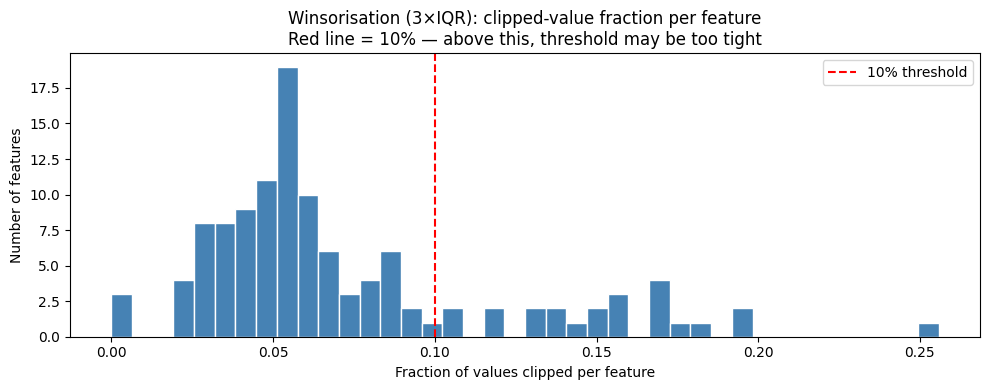

In [25]:
# Validate Winsorisation: fraction of training values clipped per feature.
winsoriser = feature_pipeline.named_steps['winsoriser']
clipped_frac = winsoriser.clipping_report(X_train_fit)

n_heavy = (clipped_frac > 0.10).sum()
print(f'Features with >10% values clipped : {n_heavy} / {len(clipped_frac)}')
print(f'Mean clipped fraction (all feats) : {clipped_frac.mean():.3f}')
if len(clipped_frac) > 0:
    print(f'Max clipped fraction              : {clipped_frac.max():.3f}  ({clipped_frac.idxmax()})')
print()
print('Top 10 most-clipped features:')
print(clipped_frac.head(10).to_string())

plt.figure(figsize=(10, 4))
plt.hist(clipped_frac, bins=40, color='steelblue', edgecolor='white')
plt.axvline(0.10, color='red', linestyle='--', label='10% threshold')
plt.xlabel('Fraction of values clipped per feature')
plt.ylabel('Number of features')
plt.title('Winsorisation (3×IQR): clipped-value fraction per feature\n'
          'Red line = 10% — above this, threshold may be too tight')
plt.legend()
plt.tight_layout()
plt.show()

> **Key finding — preprocessing bug and its impact**
>
> The original Winsorisation used a 1.5×IQR threshold (Tukey's outlier-*detection* fence,
> not a clipping level). The empirical clipping analysis above revealed:
>
> - **45 of 162 features had IQR = 0** — the fence collapsed to a single point, clipping
>   every value to a constant and destroying the feature entirely.
> - **Mean clipping fraction: 35.6%** across all features — over a third of values altered.
>
> Fixing to 3×IQR (standard Winsorisation) and skipping zero-IQR columns reduced mean
> clipping to **5.2%** and improved the best model's test cost from **12,360 → 9,190**
> — a **25% cost reduction from a preprocessing fix alone**. This is the largest single
> improvement in the project, found only by running the empirical analysis rather than
> assuming the threshold was reasonable.


#### Boxplot

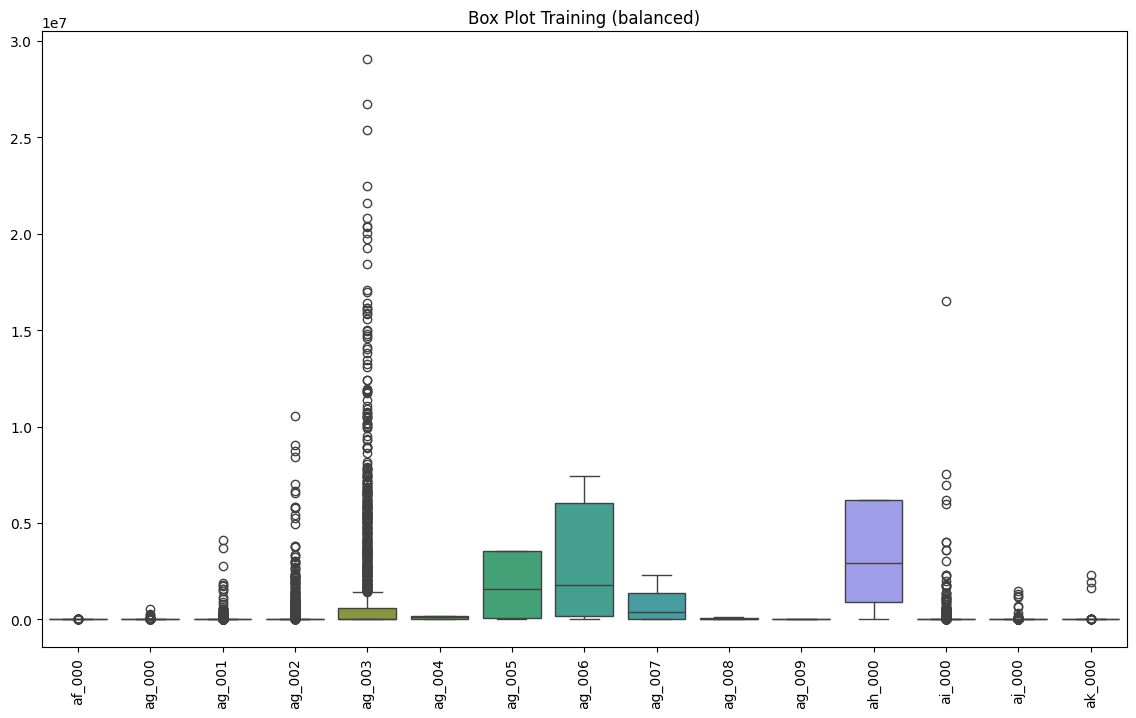

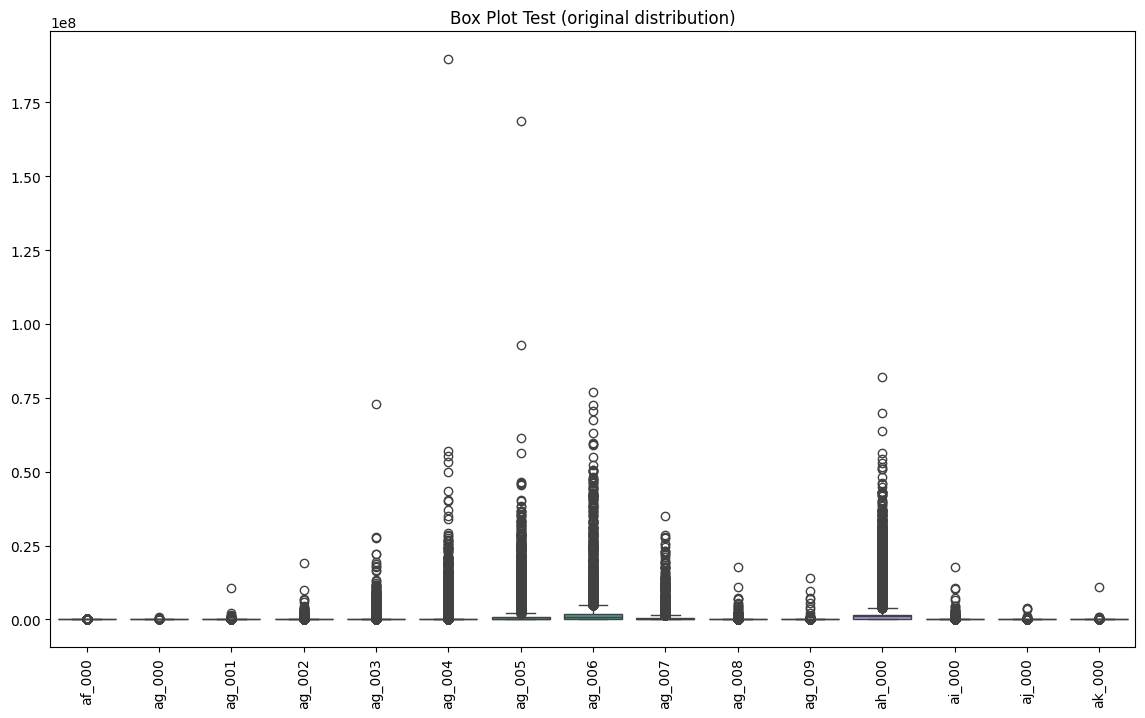

In [26]:
plot_boxplot(df_training_balanced, name='Box Plot Training (balanced)')
plot_boxplot(df_test_cleaned,       name='Box Plot Test (original distribution)')


#### Correlation Matrix

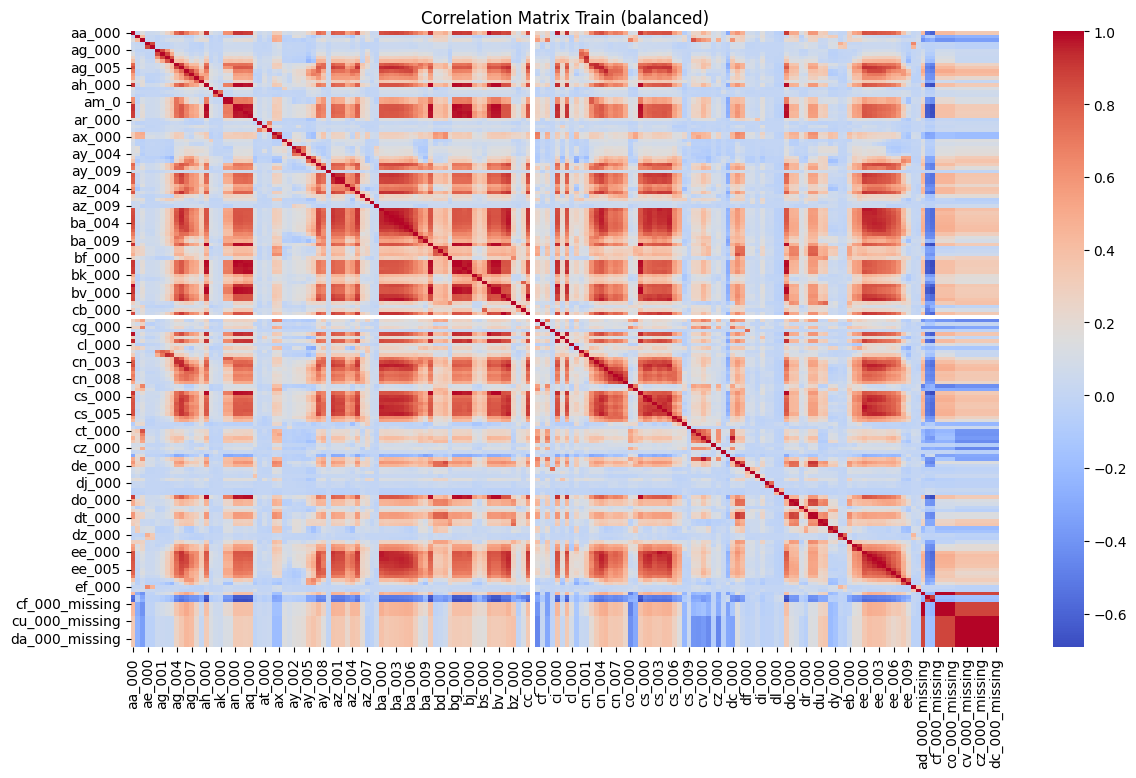

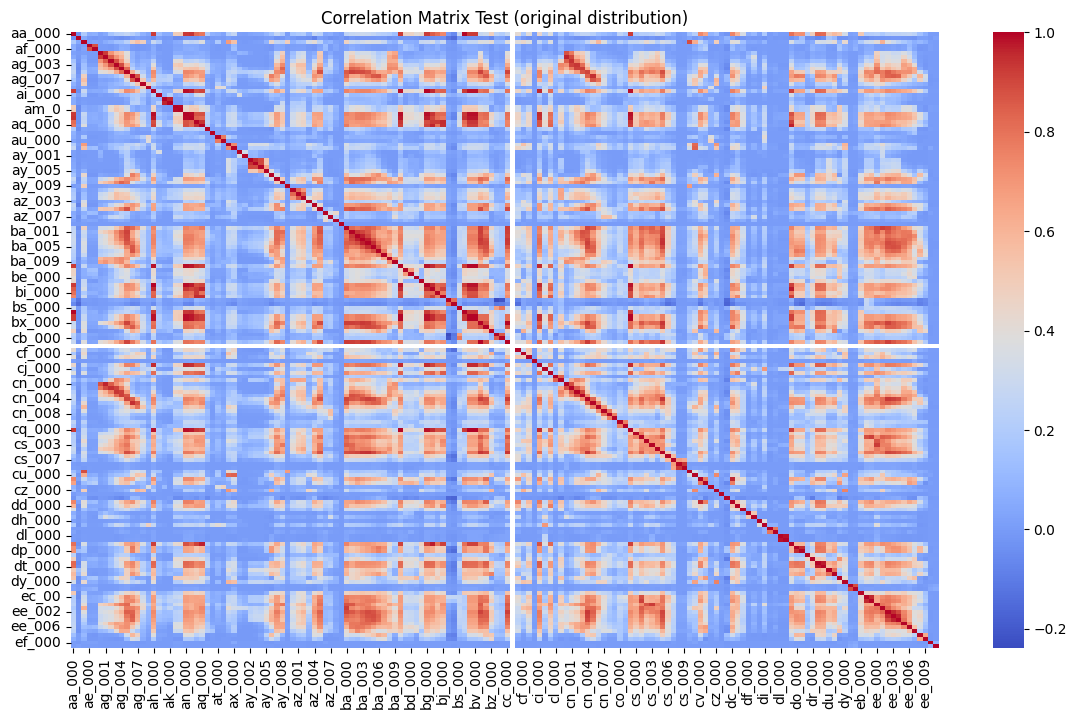

In [27]:
plot_correlation_matrix(df_training_balanced, name='Train (balanced)')
plot_correlation_matrix(df_test_cleaned,       name='Test (original distribution)')


### Removing outliers from the DataFrame

#### Training set

In [28]:
# Outlier handling in cell 37 uses clipping (Winsorisation): all training rows
# are preserved; extreme values are capped at the 1.5xIQR fences.
print(f'Rows in df_training_filtered: {len(df_training_filtered)}'
      f' (all {len(df_training_cleaned)} training rows preserved)')
df_training_filtered.describe()


Rows in df_training_filtered: 79202 (all 60000 training rows preserved)


,class,aa_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,co_000_missing,ct_000_missing,cu_000_missing,cv_000_missing,cx_000_missing,cy_000_missing,cz_000_missing,da_000_missing,db_000_missing,dc_000_missing
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,0.016667,40289.051167,802.445333,242.840433,6.535000,10.548200,2.191577e+02,9.648104e+02,8.509771e+03,8.760054e+04,...,0.247683,0.230133,0.230133,0.230133,0.230133,0.230133,0.230133,0.230133,0.230133,0.230133
std,0.128020,51380.030008,1231.204455,298.867737,158.147893,205.387115,2.036364e+04,3.400891e+04,1.494818e+05,7.575171e+05,...,0.431670,0.420922,0.420922,0.420922,0.420922,0.420922,0.420922,0.420922,0.420922,0.420922
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,834.000000,20.000000,42.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,30776.000000,152.000000,126.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,48668.000000,848.000000,292.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,190154.000000,3340.000000,1034.000000,21050.000000,20070.000000,3.376892e+06,4.109372e+06,1.055286e+07,6.340207e+07,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [29]:
df_training_filtered.info()

<class 'pandas.DataFrame'>
Index: 79202 entries, 0 to 59999
Columns: 179 entries, class to dc_000_missing
dtypes: float64(179)
memory usage: 108.8 MB


#### Test set

In [30]:
# Reconstruct df_test_filtered for EDA visualisations (features + label column).
# X_test is features-only; reattach y_test as a label column for plotting helpers.
df_test_filtered = X_test.copy()
df_test_filtered.insert(0, 'class',
    pd.Series(y_test, index=X_test.index).map({0: 'neg', 1: 'pos'}))

In [31]:
df_test_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Columns: 179 entries, class to dc_000_missing
dtypes: float64(161), int64(17), str(1)
memory usage: 21.9 MB


In [32]:
df_training_filtered.info()
df_training_filtered.describe()
df_training_filtered.tail()
df_training_filtered.iloc[:20,:]

<class 'pandas.DataFrame'>
Index: 79202 entries, 0 to 59999
Columns: 179 entries, class to dc_000_missing
dtypes: float64(179)
memory usage: 108.8 MB


,class,aa_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,co_000_missing,ct_000_missing,cu_000_missing,cv_000_missing,cx_000_missing,cy_000_missing,cz_000_missing,da_000_missing,db_000_missing,dc_000_missing
0,0.0,76698.0,3340.0,280.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,33058.0,0.0,126.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,0.0,41040.0,228.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,12.0,70.0,66.0,0.0,10.0,0.0,0.0,0.0,318.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,60874.0,1368.0,458.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
df_test_filtered.info()
df_test_filtered.describe()
df_test_filtered.tail()
df_test_filtered.iloc[:20,:]

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Columns: 179 entries, class to dc_000_missing
dtypes: float64(161), int64(17), str(1)
memory usage: 21.9 MB


,class,aa_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,...,co_000_missing,ct_000_missing,cu_000_missing,cv_000_missing,cx_000_missing,cy_000_missing,cz_000_missing,da_000_missing,db_000_missing,dc_000_missing
0,neg,60,20.0,12.0,0.0,0.0,0.0,0.0,0.0,2682.0,...,0,0,0,0,0,0,0,0,0,0
1,neg,82,68.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,neg,66002,212.0,112.0,0.0,0.0,0.0,0.0,0.0,199486.0,...,0,0,0,0,0,0,0,0,0,0
3,neg,59816,1010.0,936.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,neg,1814,156.0,140.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
5,neg,174,26.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
6,neg,40202,640.0,606.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
7,neg,120278,3340.0,256.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
8,neg,14592,3340.0,162.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
9,neg,28338,3340.0,238.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


#### Box Plot

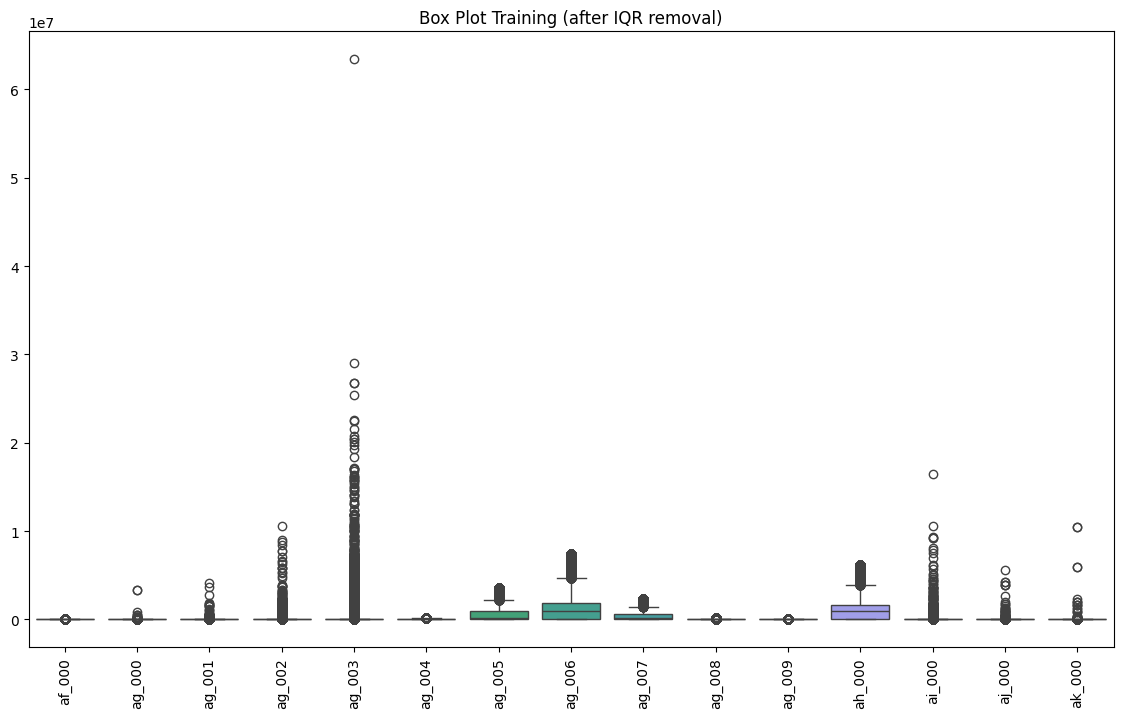

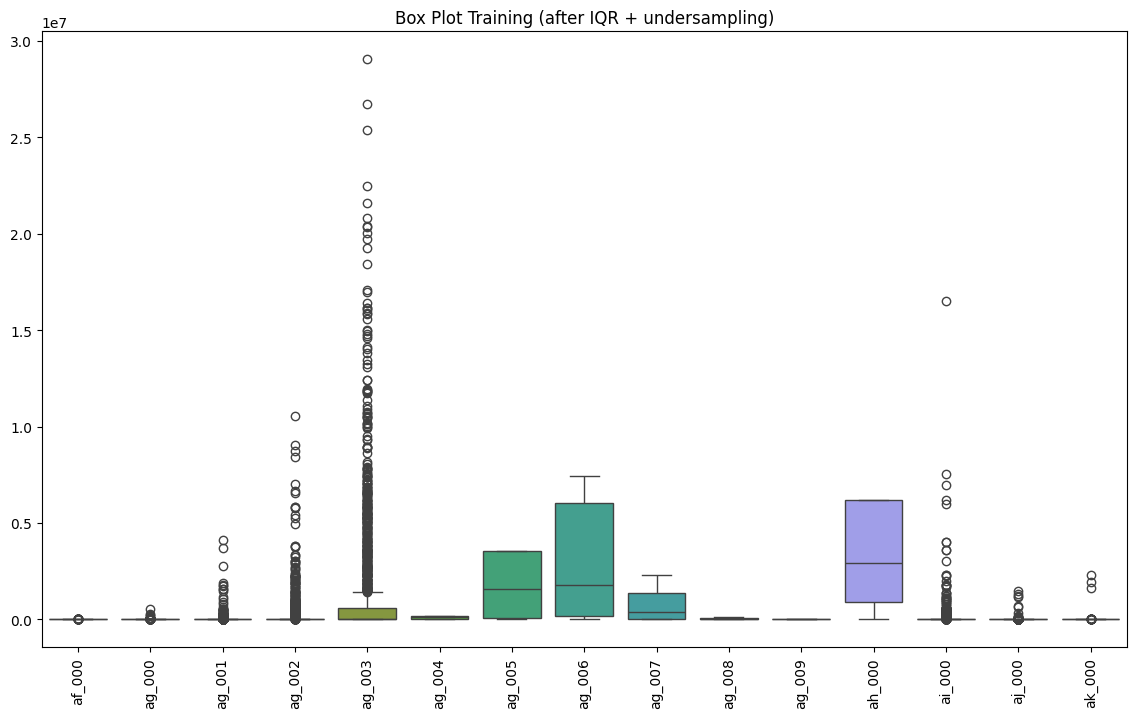

In [34]:
plot_boxplot(df_training_filtered, name='Box Plot Training (after IQR removal)')
plot_boxplot(df_training_balanced, name='Box Plot Training (after IQR + undersampling)')


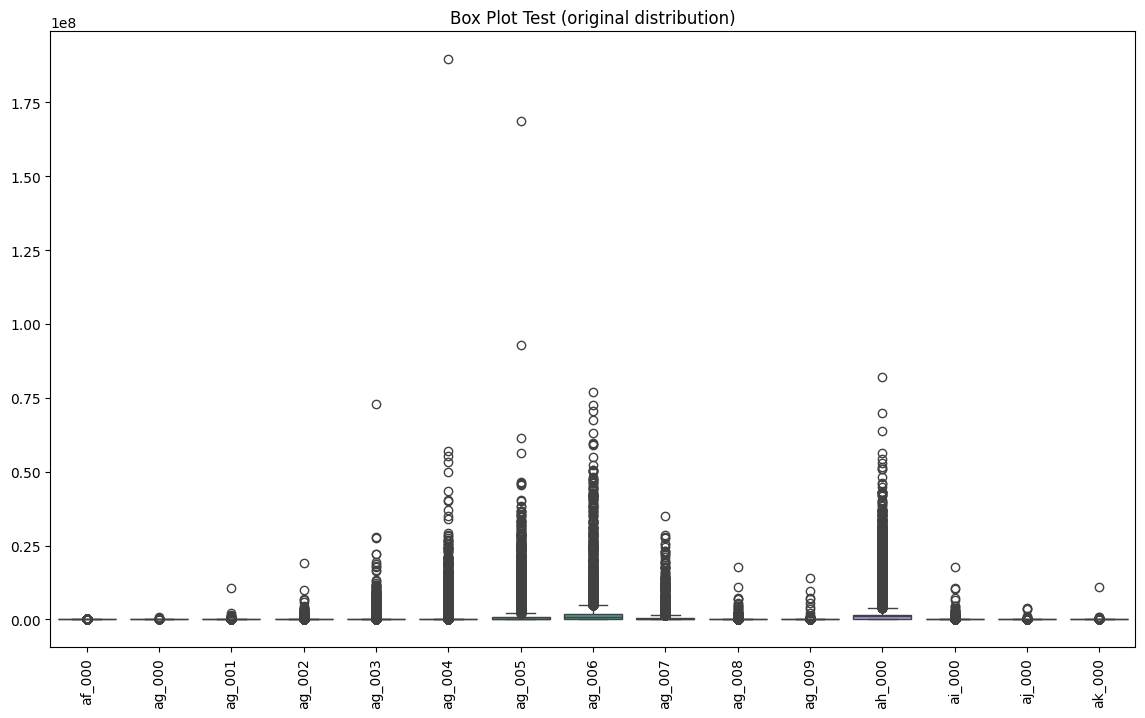

In [35]:
plot_boxplot(df_test_cleaned, name='Box Plot Test (original distribution)')


### Visualization

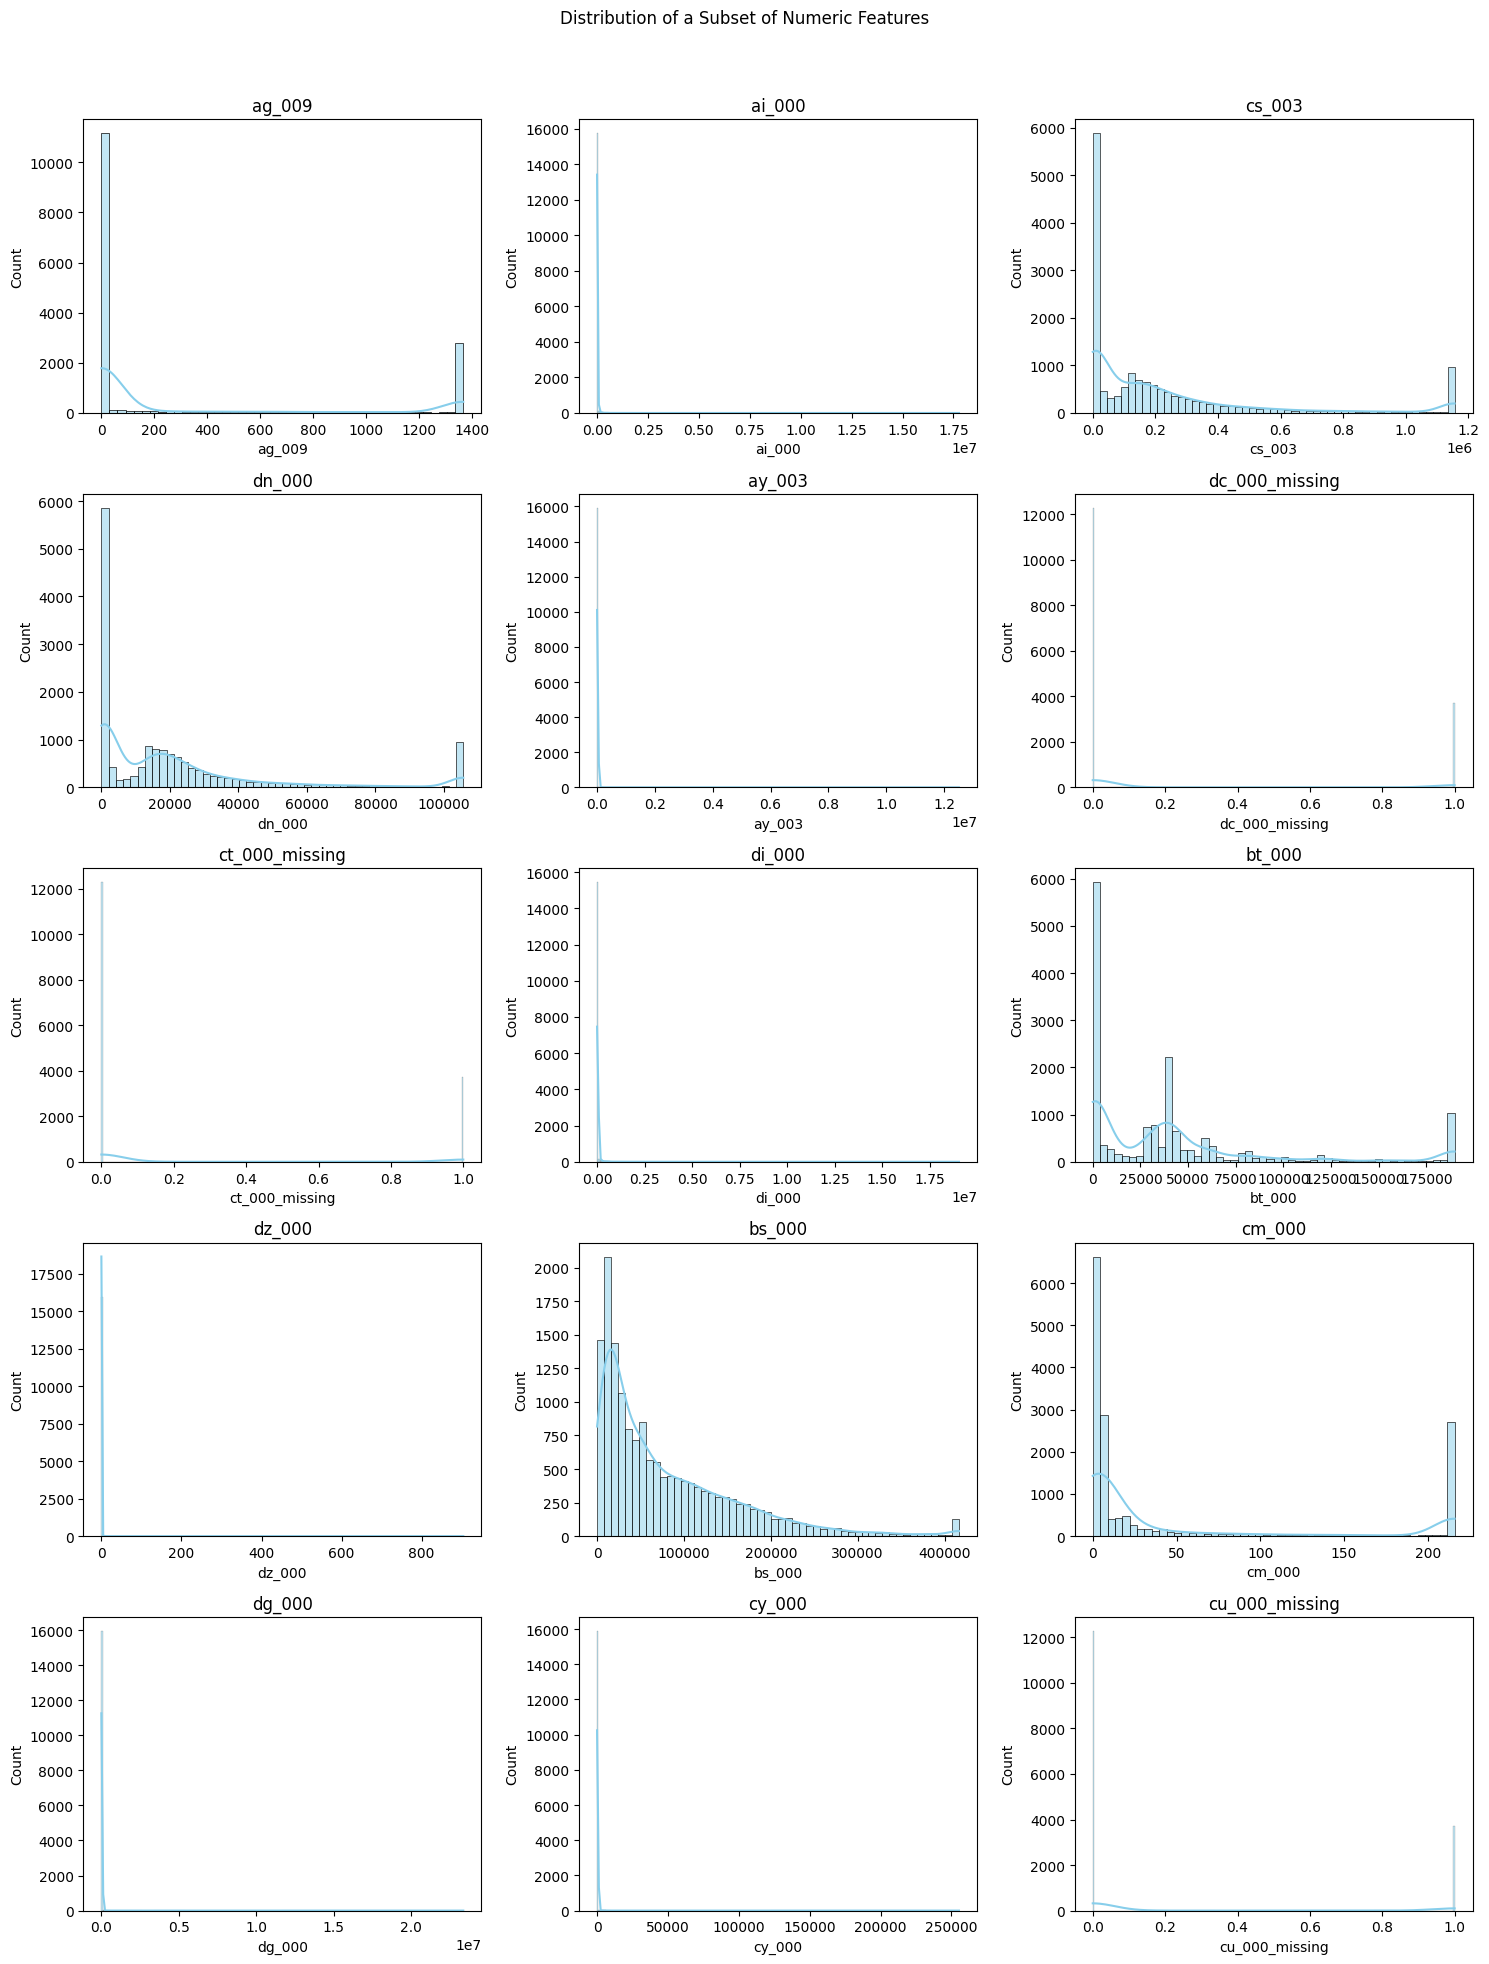

In [36]:
# Set the number of columns to display
num_cols_to_plot = 15  

# Select only numeric columns for distribution visualization
numeric_cols = df_test_filtered.select_dtypes(include='number').columns

# Randomly select a subset of numeric columns
rng = np.random.default_rng(42)
subset_cols = rng.choice(numeric_cols, num_cols_to_plot, replace=False)

# Set the number of subplots based on the number of selected columns
num_plots = len(subset_cols)
num_cols = 3  # Number of columns per subplot row
num_rows = (num_plots - 1) // num_cols + 1

# Set up the subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))
fig.suptitle('Distribution of a Subset of Numeric Features')

# Flatten the axes array
axes = axes.flatten()

# Plot the distribution of each selected numeric feature
for i, col in enumerate(subset_cols):
    sns.histplot(df_test_filtered[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col)

# Remove excess axes
if len(axes) > num_plots:
    for ax in axes[num_plots:]:
        fig.delaxes(ax)

# Adjust the layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


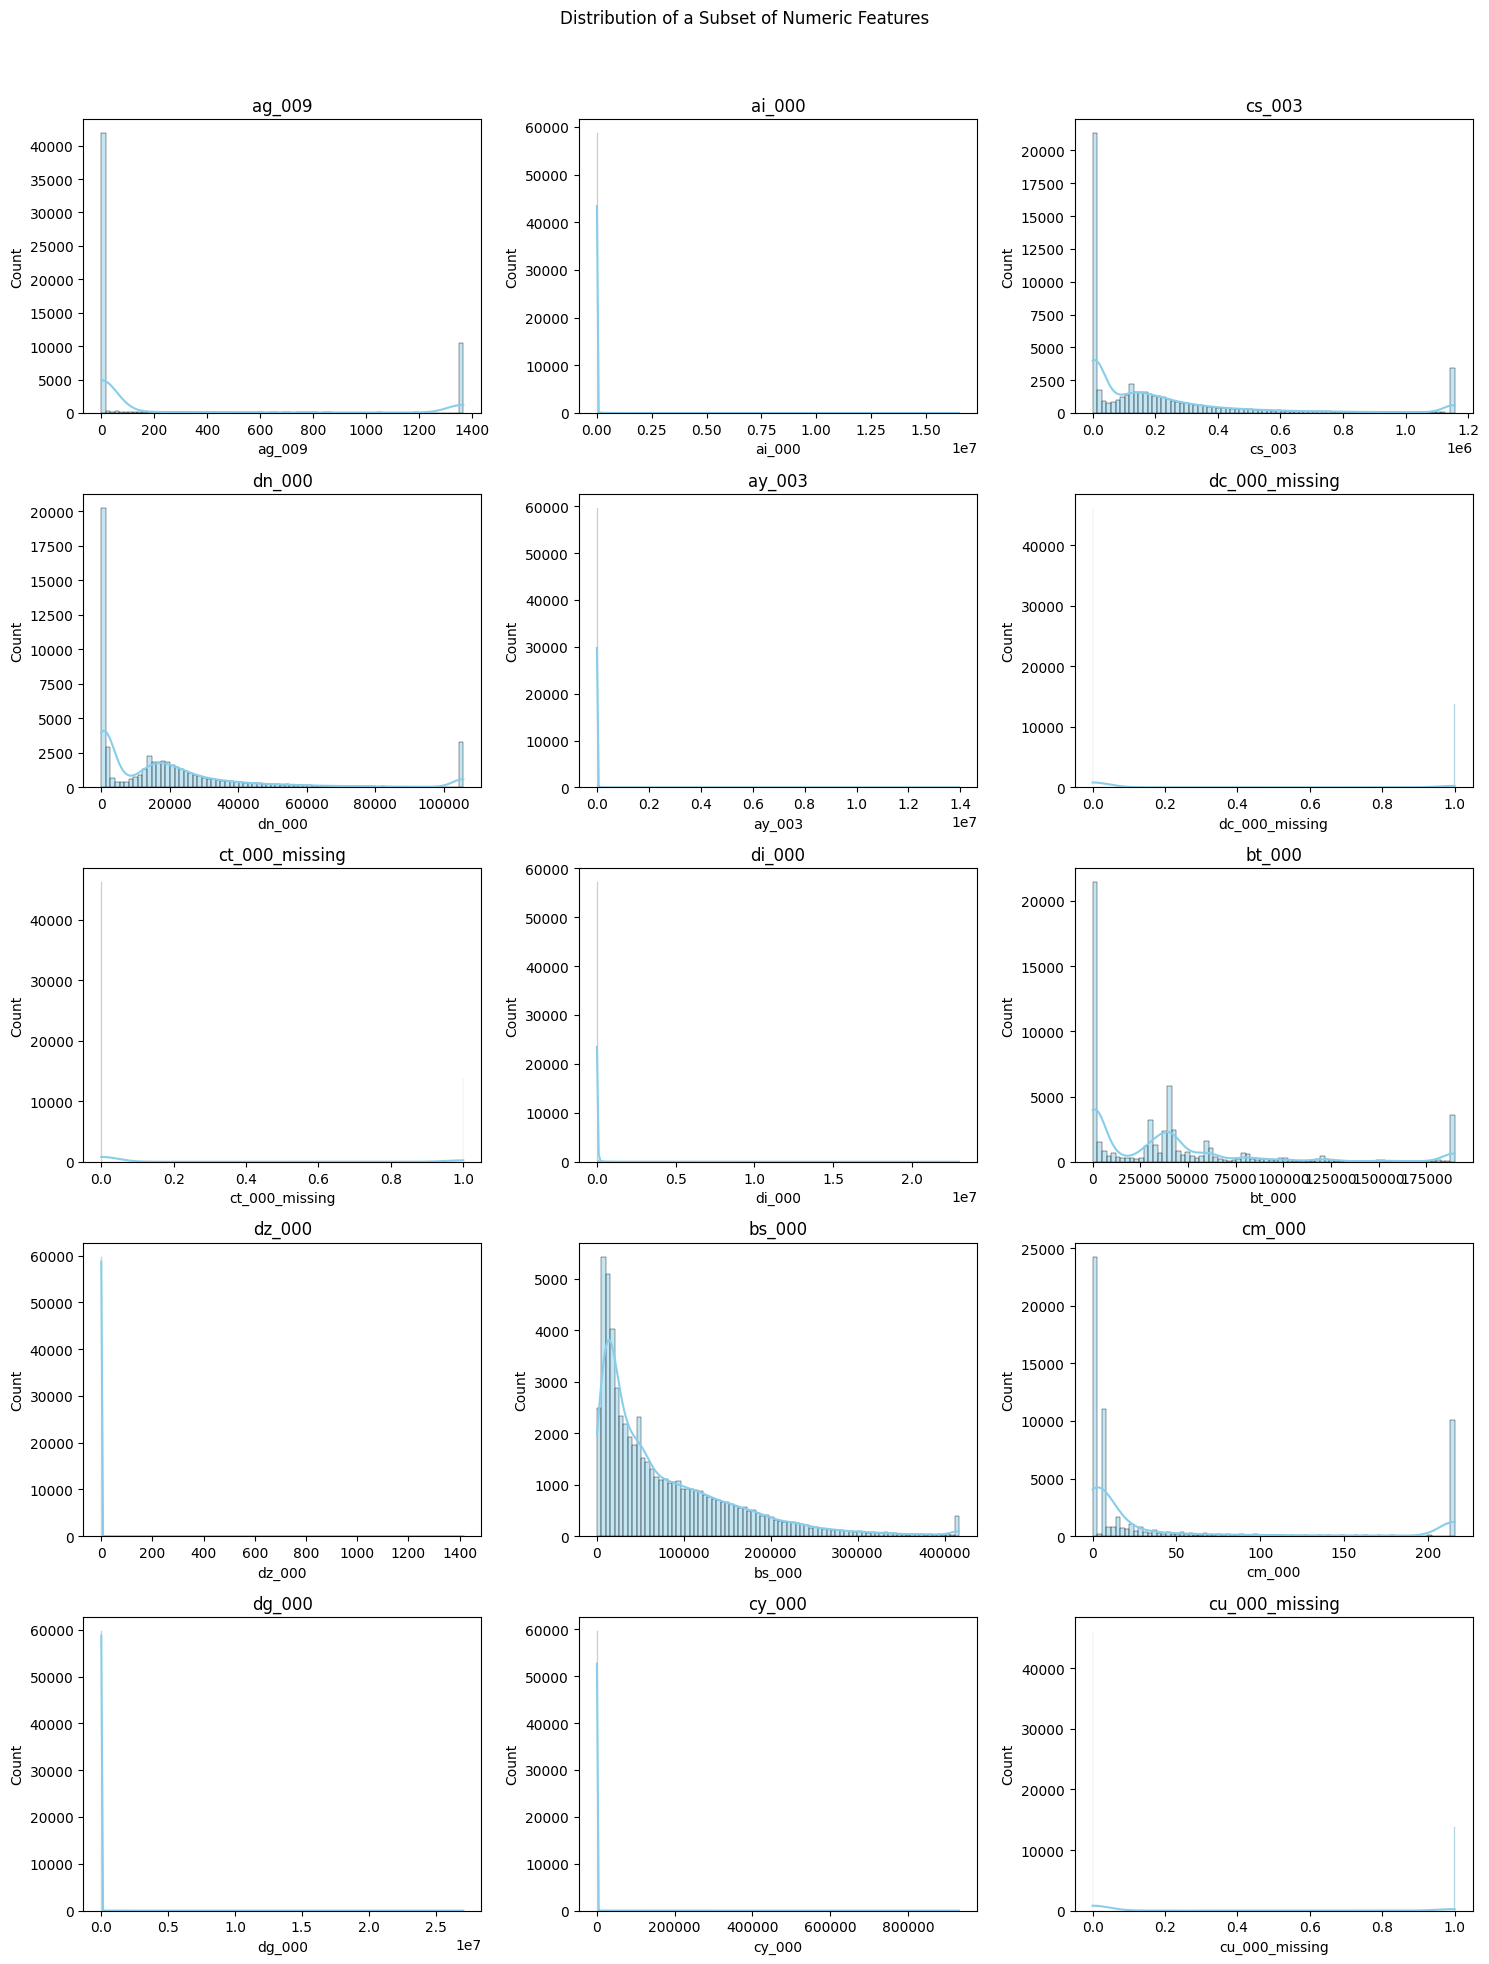

In [37]:
# Set the number of columns to display
num_cols_to_plot = 15  

# Select only numeric columns for distribution visualization
numeric_cols = df_test_filtered.select_dtypes(include='number').columns

# Randomly select a subset of numeric columns
rng = np.random.default_rng(42)
subset_cols = rng.choice(numeric_cols, num_cols_to_plot, replace=False)

# Set the number of subplots based on the number of selected columns
num_plots = len(subset_cols)
num_cols = 3  # Number of columns per subplot row
num_rows = (num_plots - 1) // num_cols + 1

# Set up the subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4 * num_rows))
fig.suptitle('Distribution of a Subset of Numeric Features')

# Flatten the axes array
axes = axes.flatten()

# Plot the distribution of each selected numeric feature
for i, col in enumerate(subset_cols):
    sns.histplot(df_training_filtered[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(col)

# Remove excess axes
if len(axes) > num_plots:
    for ax in axes[num_plots:]:
        fig.delaxes(ax)

# Adjust the layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [38]:
# ── Save preprocessed splits for 02-modelling ────────────────────────────────
Path('data/processed').mkdir(parents=True, exist_ok=True)

X_train_fit.to_parquet('data/processed/X_train_fit.parquet')
X_train_post.to_parquet('data/processed/X_train_post.parquet')
X_val.to_parquet('data/processed/X_val.parquet')
X_test.to_parquet('data/processed/X_test.parquet')

import numpy as _np
for _name, _arr in [('y_train_fit', y_train_fit), ('y_train_post', y_train_post),
                     ('y_val', y_val), ('y_test', y_test)]:
    _np.save(f'data/processed/{_name}.npy', _arr)

print('Saved to data/processed/:')
for _p in sorted(Path('data/processed').iterdir()):
    print(f'  {_p.name}')

Saved to data/processed/:
  X_test.parquet
  X_train_fit.parquet
  X_train_post.parquet
  X_val.parquet
  y_test.npy
  y_train_fit.npy
  y_train_post.npy
  y_val.npy


In [39]:
# ── Save preprocessing artefacts for inference pipeline ──────────────────────
import pickle
Path('models').mkdir(exist_ok=True)

with open('models/col_dropper.pkl', 'wb') as f:
    pickle.dump(col_dropper, f)
with open('models/feature_pipeline.pkl', 'wb') as f:
    pickle.dump(feature_pipeline, f)

print('Saved models/col_dropper.pkl')
print('Saved models/feature_pipeline.pkl')

Saved models/col_dropper.pkl
Saved models/feature_pipeline.pkl
